# QM 640 Capstone — Exploratory Data Analysis

**Notebook:** `02_EDA.ipynb`  
**Input:** `data/processed/catastrophe_dataset.csv`  
**Output folders:** `figures/` and `report_ready_tables/`

This notebook conducts exploratory analysis of the integrated NOAA, NFIP, and Census ACS county-year dataset. It supports:

- **RQ1:** Hazard drivers of catastrophe severity
- **RQ2:** Socioeconomic moderation effects
- **RQ3:** Classification of high-severity events
- **RQ4:** Long-term severity trends

All figures are saved at 300 DPI. Statistical results in this notebook are exploratory and should not be treated as final confirmatory model results.


In [1]:
from pathlib import Path
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_FILE = ROOT / "data" / "processed" / "catastrophe_dataset.csv"
FIGURE_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "report_ready_tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE, dtype={"county_fips": "string"})
df["county_fips"] = df["county_fips"].str.zfill(5)

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

print("Dataset shape:", df.shape)
print("Years:", df["year"].min(), "to", df["year"].max())
print("Unique counties:", df["county_fips"].nunique())


Dataset shape: (903, 40)
Years: 2000 to 2023
Unique counties: 50


## 1. Dataset overview

,Metric,Value
0,Rows,903
1,Columns,40
2,Minimum year,2000
3,Maximum year,2023
4,Unique counties,50
5,Missing values,0
6,Duplicate county-year keys,0


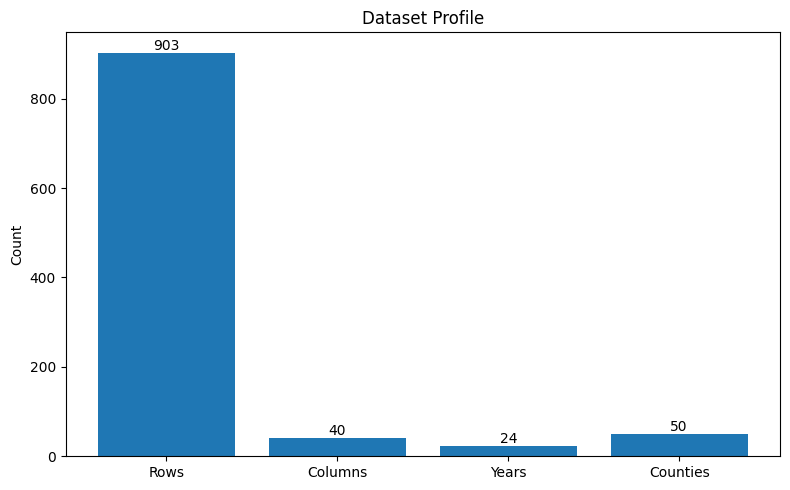

In [2]:
dataset_overview = pd.DataFrame([
    ["Rows", len(df)],
    ["Columns", df.shape[1]],
    ["Minimum year", df["year"].min()],
    ["Maximum year", df["year"].max()],
    ["Unique counties", df["county_fips"].nunique()],
    ["Missing values", int(df.isna().sum().sum())],
    ["Duplicate county-year keys", int(df.duplicated(["year", "county_fips"]).sum())],
], columns=["Metric", "Value"])
dataset_overview.to_csv(TABLE_DIR / "01_dataset_overview.csv", index=False)
display(dataset_overview)

plt.figure(figsize=(8, 5))
labels = ["Rows", "Columns", "Years", "Counties"]
values = [len(df), df.shape[1], df["year"].nunique(), df["county_fips"].nunique()]
plt.bar(labels, values)
plt.title("Dataset Profile")
plt.ylabel("Count")
for index, value in enumerate(values):
    plt.text(index, value, f"{value:,}", ha="center", va="bottom")
save_figure("figure_01_dataset_profile.png")


**Interpretation.** The analysis dataset contains **903 county-year observations** and **40 variables**. It has no remaining missing values or duplicate county-year keys, so it is ready for exploratory analysis and baseline modeling.

,Variable Type,Count
0,Numeric,35
1,Categorical/Text,5
2,Binary flags,12


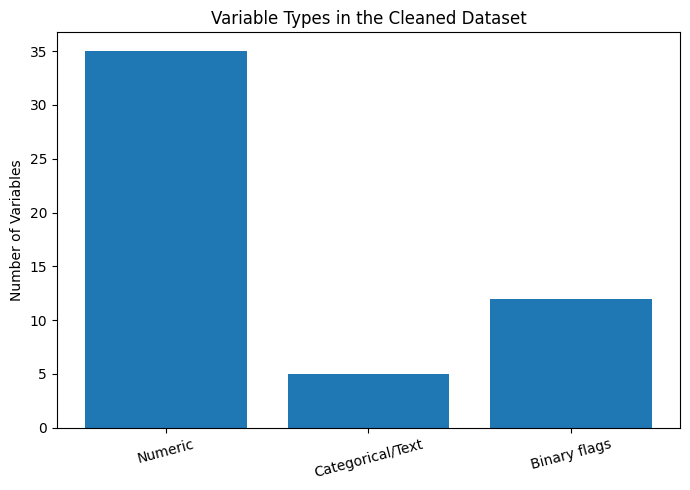

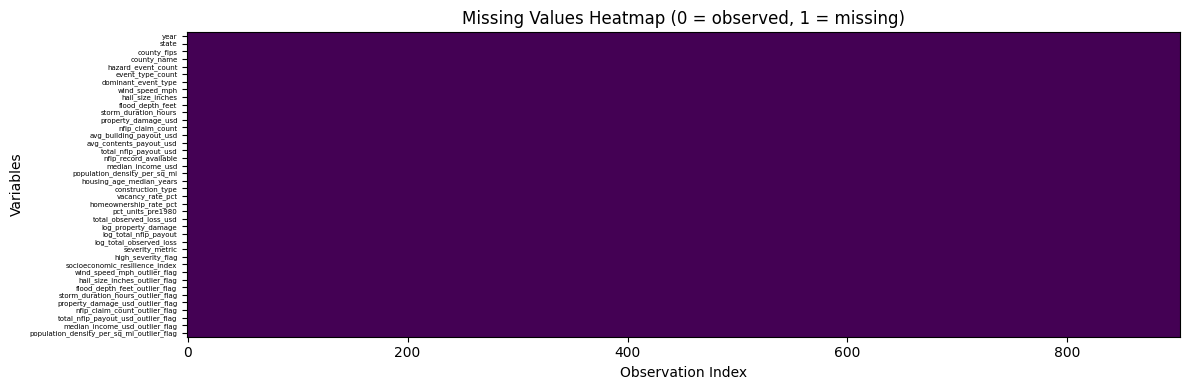

In [3]:
variable_type_summary = pd.DataFrame({
    "Variable Type": ["Numeric", "Categorical/Text", "Binary flags"],
    "Count": [
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1],
        sum(df[column].dropna().nunique() <= 2 for column in df.columns),
    ],
})
variable_type_summary.to_csv(TABLE_DIR / "02_variable_types.csv", index=False)
display(variable_type_summary)

plt.figure(figsize=(7, 5))
plt.bar(variable_type_summary["Variable Type"], variable_type_summary["Count"])
plt.title("Variable Types in the Cleaned Dataset")
plt.ylabel("Number of Variables")
plt.xticks(rotation=15)
save_figure("figure_02_variable_types.png")

missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Missing Count": df.isna().sum().values,
    "Missing Percentage": (df.isna().mean().values * 100).round(2),
})
missing_summary.to_csv(TABLE_DIR / "04_missing_value_summary.csv", index=False)

plt.figure(figsize=(12, 4))
plt.imshow(df.isna().astype(int).T.values, aspect="auto", interpolation="nearest")
plt.title("Missing Values Heatmap (0 = observed, 1 = missing)")
plt.xlabel("Observation Index")
plt.ylabel("Variables")
plt.yticks(range(len(df.columns)), df.columns, fontsize=5)
save_figure("figure_03_missing_values_heatmap.png")


## 2. Hazard analysis

,Event Type,County-Year Count
0,Thunderstorm Wind,303
1,Flash Flood,180
2,Hail,170
3,Tornado,131
4,Winter Storm,92
5,Hurricane (Typhoon),23
6,Wildfire,4


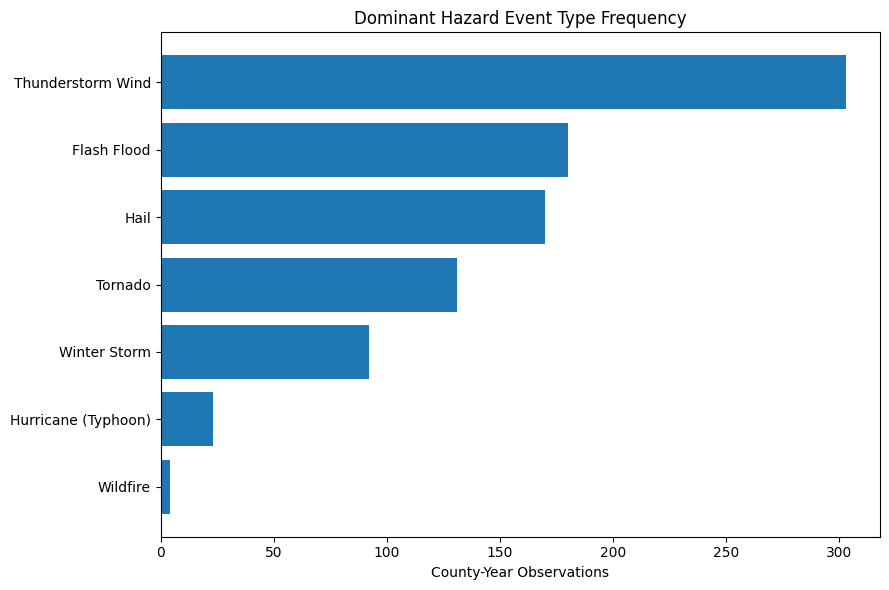

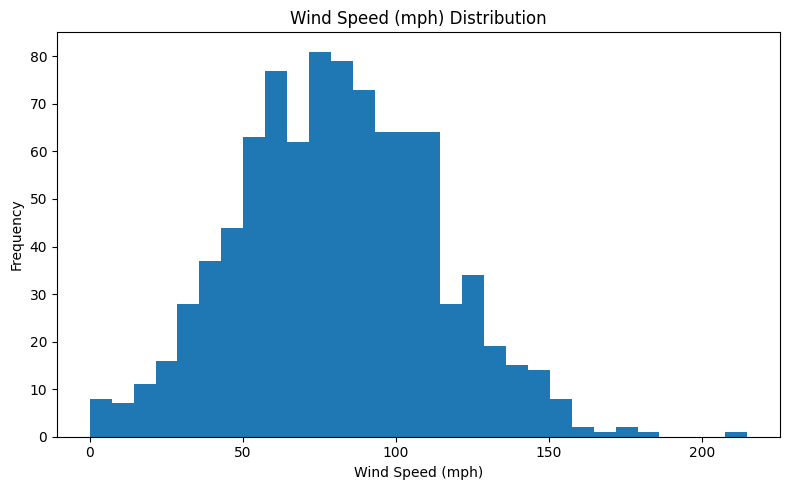

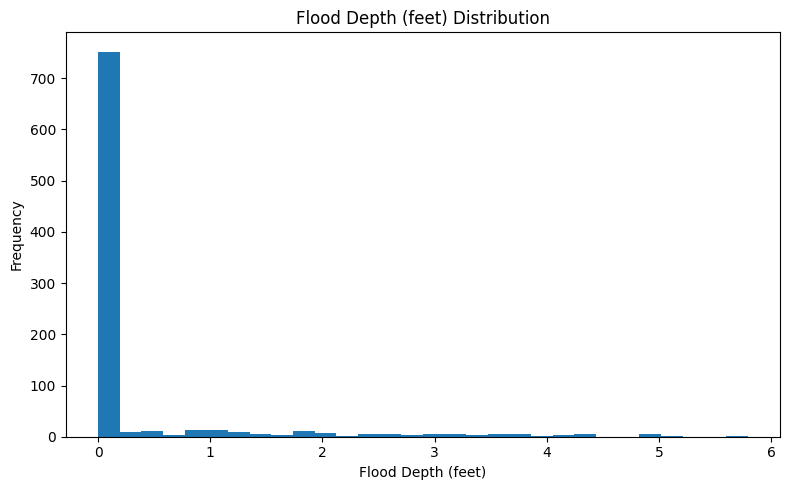

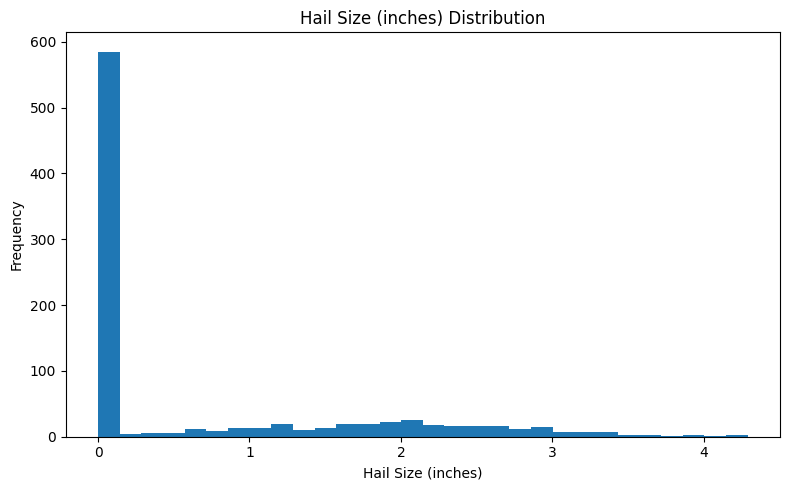

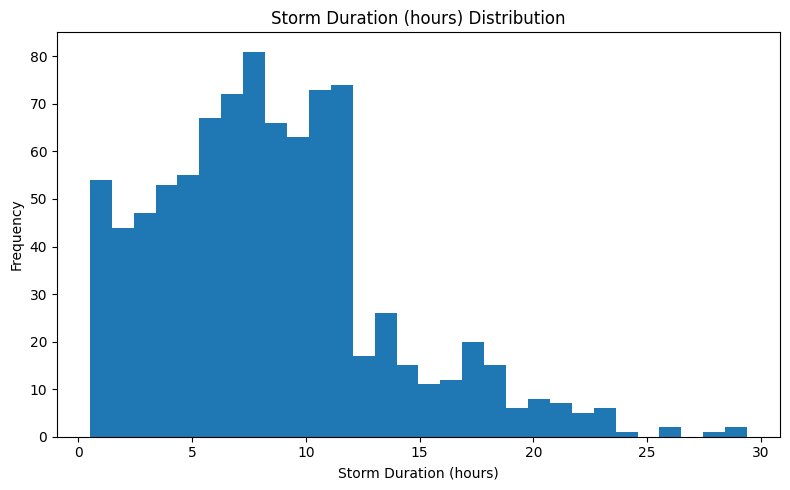

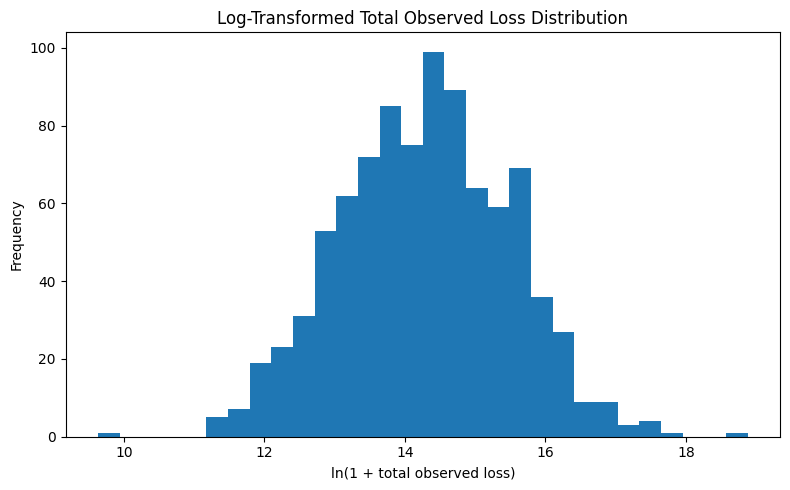

In [4]:
event_frequency = df["dominant_event_type"].value_counts().reset_index()
event_frequency.columns = ["Event Type", "County-Year Count"]
event_frequency.to_csv(TABLE_DIR / "05_event_type_frequency.csv", index=False)
display(event_frequency)

plt.figure(figsize=(9, 6))
event_plot = event_frequency.sort_values("County-Year Count")
plt.barh(event_plot["Event Type"], event_plot["County-Year Count"])
plt.title("Dominant Hazard Event Type Frequency")
plt.xlabel("County-Year Observations")
save_figure("figure_04_event_type_frequency.png")

hazard_variables = [
    ("wind_speed_mph", "Wind Speed (mph)", "figure_05_wind_speed_distribution.png"),
    ("flood_depth_feet", "Flood Depth (feet)", "figure_06_flood_depth_distribution.png"),
    ("hail_size_inches", "Hail Size (inches)", "figure_07_hail_size_distribution.png"),
    ("storm_duration_hours", "Storm Duration (hours)", "figure_08_storm_duration_distribution.png"),
]
for variable, label, filename in hazard_variables:
    plt.figure(figsize=(8, 5))
    plt.hist(df[variable], bins=30)
    plt.title(f"{label} Distribution")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    save_figure(filename)

plt.figure(figsize=(8, 5))
plt.hist(df["log_total_observed_loss"], bins=30)
plt.title("Log-Transformed Total Observed Loss Distribution")
plt.xlabel("ln(1 + total observed loss)")
plt.ylabel("Frequency")
save_figure("figure_09_log_loss_distribution.png")


**Interpretation.** The hazard distributions are generally right-skewed and include extreme observations. These extremes were retained because unusually intense hazards and large losses are central to catastrophe-risk analysis. Log transformation makes financial loss distributions more suitable for visualization and later modeling without deleting tail events.

## 3. Severity analysis

,Percentile,Severity Metric
0,0.00,0.138853
1,0.10,0.299989
2,0.25,0.335878
3,0.50,0.382999
4,0.75,0.452989
5,0.80,0.469292
6,0.90,0.503529
7,0.95,0.547338
8,0.99,0.599028
9,1.00,0.654598


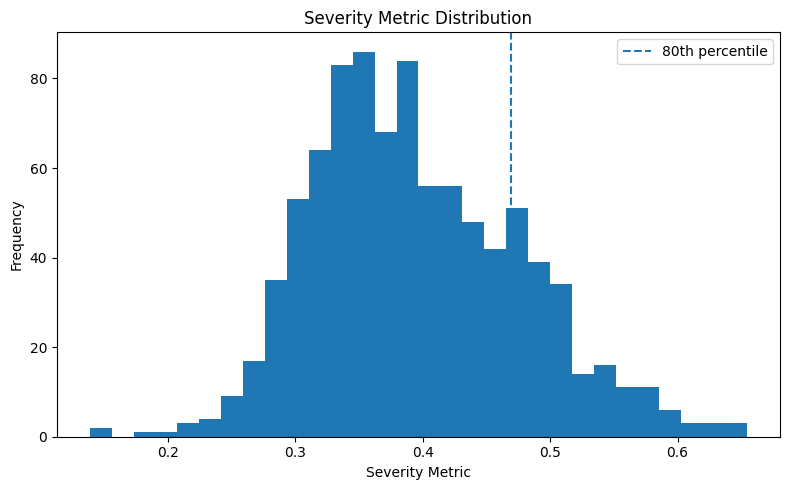

,dominant_event_type,count,mean,median,max
2,Hurricane (Typhoon),23,0.488753,0.484632,0.594307
1,Hail,170,0.451117,0.450963,0.654598
4,Tornado,131,0.439937,0.433365,0.581867
0,Flash Flood,180,0.392801,0.380550,0.638079
3,Thunderstorm Wind,303,0.359165,0.352313,0.568990
6,Winter Storm,92,0.329734,0.325155,0.453678
5,Wildfire,4,0.299698,0.295453,0.355579


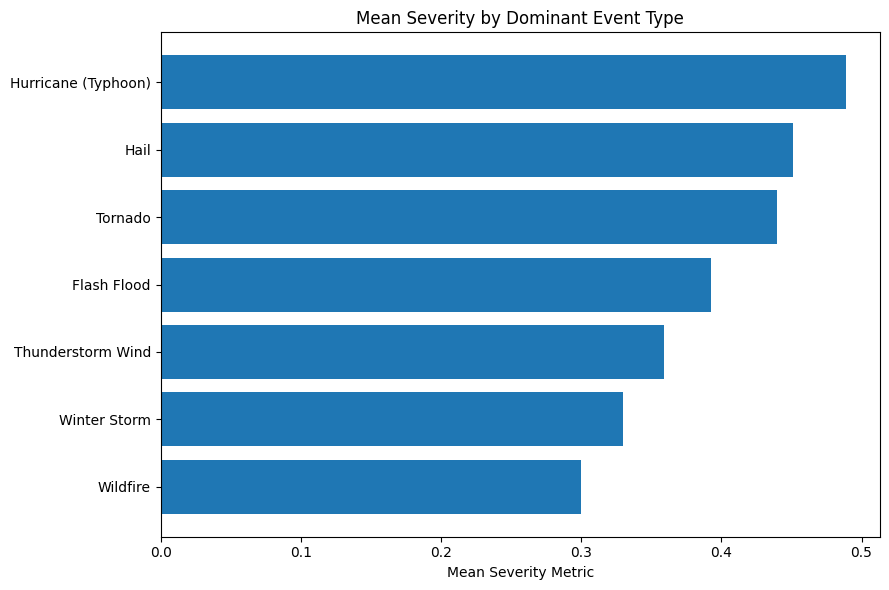

In [5]:
severity_percentiles = df["severity_metric"].quantile(
    [0, .10, .25, .50, .75, .80, .90, .95, .99, 1]
).reset_index()
severity_percentiles.columns = ["Percentile", "Severity Metric"]
severity_percentiles.to_csv(TABLE_DIR / "06_severity_percentiles.csv", index=False)
display(severity_percentiles)

severity_threshold = df["severity_metric"].quantile(.80)
plt.figure(figsize=(8, 5))
plt.hist(df["severity_metric"], bins=30)
plt.axvline(severity_threshold, linestyle="--", label="80th percentile")
plt.title("Severity Metric Distribution")
plt.xlabel("Severity Metric")
plt.ylabel("Frequency")
plt.legend()
save_figure("figure_10_severity_distribution.png")

severity_by_event = (
    df.groupby("dominant_event_type")["severity_metric"]
      .agg(["count", "mean", "median", "max"])
      .reset_index()
      .sort_values("mean", ascending=False)
)
severity_by_event.to_csv(TABLE_DIR / "07_severity_by_event_type.csv", index=False)
display(severity_by_event)

plt.figure(figsize=(9, 6))
event_severity_plot = severity_by_event.sort_values("mean")
plt.barh(event_severity_plot["dominant_event_type"], event_severity_plot["mean"])
plt.title("Mean Severity by Dominant Event Type")
plt.xlabel("Mean Severity Metric")
save_figure("figure_11_severity_by_event_type.png")


,year,mean_severity,median_severity,max_severity,total_property_damage,total_nfip_payout,hazard_event_count,severity_3yr_moving_average
0,2000,0.382091,0.369524,0.551375,2267918,125284961.0,50,0.377451
1,2001,0.372811,0.354305,0.516985,3480584,91622760.0,50,0.377907
2,2002,0.378819,0.365156,0.545718,2942564,80799614.0,50,0.377913
3,2003,0.382108,0.364388,0.547824,3726130,182429818.0,50,0.382578
4,2004,0.386805,0.382426,0.519411,4506794,145848142.0,50,0.388155
5,2005,0.395552,0.387772,0.609880,5242054,104165814.0,50,0.390629
6,2006,0.389531,0.380739,0.594330,3334711,107009245.0,50,0.386955
7,2007,0.375783,0.380067,0.568990,3008975,97559342.0,50,0.386051
8,2008,0.392840,0.371950,0.627807,3737502,58857076.0,50,0.387715
9,2009,0.394523,0.404089,0.529022,2594923,79267057.0,50,0.388970


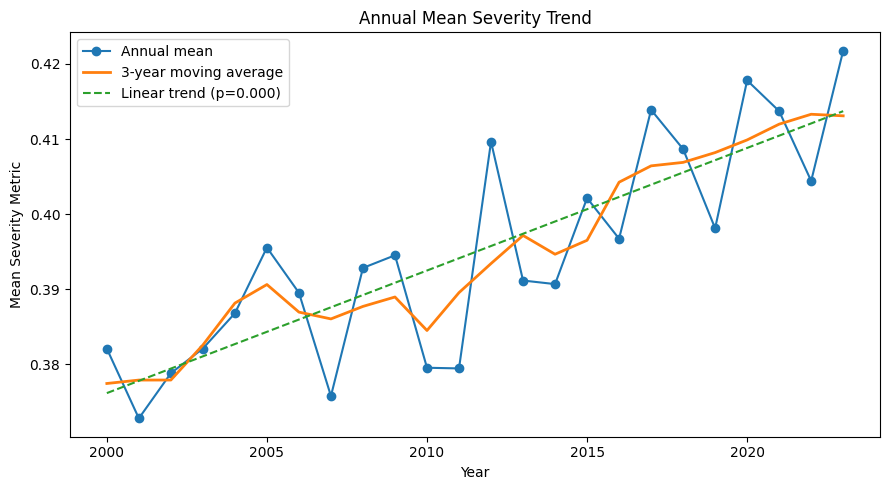

,county_fips,county_name,state,observations,mean_severity,max_severity,high_severity_count,total_observed_loss
9,12086,Miami-Dade,FL,13,0.498176,0.612412,9,56265262.0
34,40109,Oklahoma,OK,16,0.490575,0.654598,7,60474029.0
19,22071,Orleans,LA,15,0.490511,0.625031,10,155286290.0
8,12057,Hillsborough,FL,10,0.478663,0.638079,5,51456207.0
10,12095,Orange,FL,14,0.469548,0.594330,7,119171297.0
18,22033,East Baton Rouge,LA,14,0.464597,0.594307,8,102583402.0
1,01097,Mobile,AL,19,0.464080,0.594482,9,115576493.0
17,20173,Sedgwick,KS,17,0.459769,0.619141,8,53785828.0
45,48439,Tarrant,TX,10,0.457727,0.563631,6,17576412.0
15,19153,Polk,IA,24,0.452052,0.581867,9,56773361.0


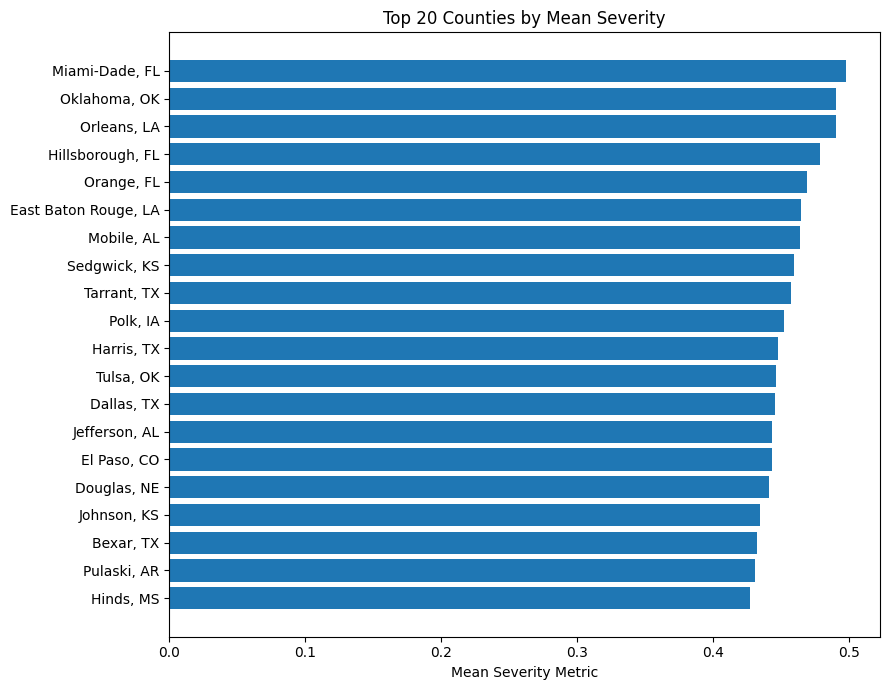

In [6]:
annual_summary = (
    df.groupby("year")
      .agg(
          mean_severity=("severity_metric", "mean"),
          median_severity=("severity_metric", "median"),
          max_severity=("severity_metric", "max"),
          total_property_damage=("property_damage_usd", "sum"),
          total_nfip_payout=("total_nfip_payout_usd", "sum"),
          hazard_event_count=("hazard_event_count", "sum"),
      )
      .reset_index()
)
annual_summary["severity_3yr_moving_average"] = (
    annual_summary["mean_severity"].rolling(3, center=True, min_periods=1).mean()
)
annual_summary.to_csv(TABLE_DIR / "08_annual_trend_summary.csv", index=False)
display(annual_summary)

trend = stats.linregress(annual_summary["year"], annual_summary["mean_severity"])
plt.figure(figsize=(9, 5))
plt.plot(annual_summary["year"], annual_summary["mean_severity"], marker="o", label="Annual mean")
plt.plot(annual_summary["year"], annual_summary["severity_3yr_moving_average"],
         linewidth=2, label="3-year moving average")
plt.plot(annual_summary["year"], trend.intercept + trend.slope * annual_summary["year"],
         linestyle="--", label=f"Linear trend (p={trend.pvalue:.3f})")
plt.title("Annual Mean Severity Trend")
plt.xlabel("Year")
plt.ylabel("Mean Severity Metric")
plt.legend()
save_figure("figure_12_annual_severity_trend.png")

county_summary = (
    df.groupby(["county_fips", "county_name", "state"])
      .agg(
          observations=("year", "count"),
          mean_severity=("severity_metric", "mean"),
          max_severity=("severity_metric", "max"),
          high_severity_count=("high_severity_flag", "sum"),
          total_observed_loss=("total_observed_loss_usd", "sum"),
      )
      .reset_index()
      .sort_values("mean_severity", ascending=False)
)
county_summary.to_csv(TABLE_DIR / "09_county_severity_summary.csv", index=False)
display(county_summary.head(20))

top_counties = county_summary.head(20)
plt.figure(figsize=(9, 7))
county_labels = top_counties["county_name"] + ", " + top_counties["state"]
plt.barh(county_labels[::-1], top_counties["mean_severity"][::-1])
plt.title("Top 20 Counties by Mean Severity")
plt.xlabel("Mean Severity Metric")
save_figure("figure_13_top_counties_by_severity.png")


**Interpretation.** The 80th-percentile cutoff defines the high-severity class without assuming a normal distribution. In the supplied data, **Hurricane (Typhoon)** has the highest mean severity among dominant event types. **Miami-Dade, FL** has the highest county-level mean severity, although this ranking describes the supplied sample and is not a population-wide causal conclusion.

## 4. Socioeconomic analysis

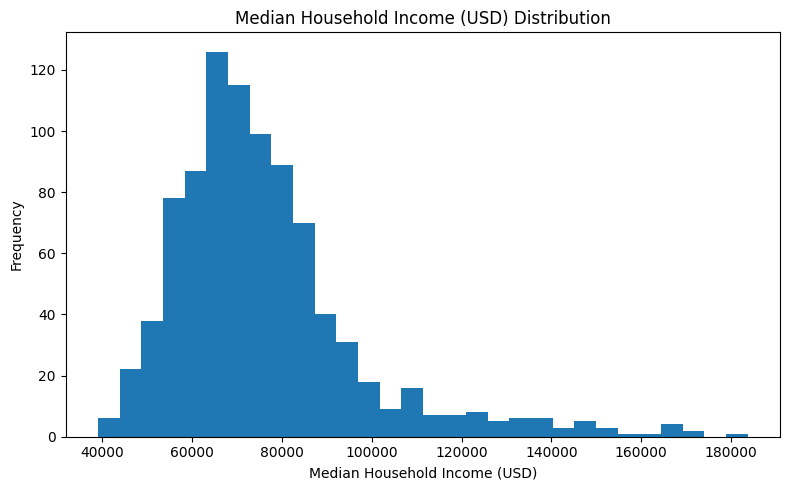

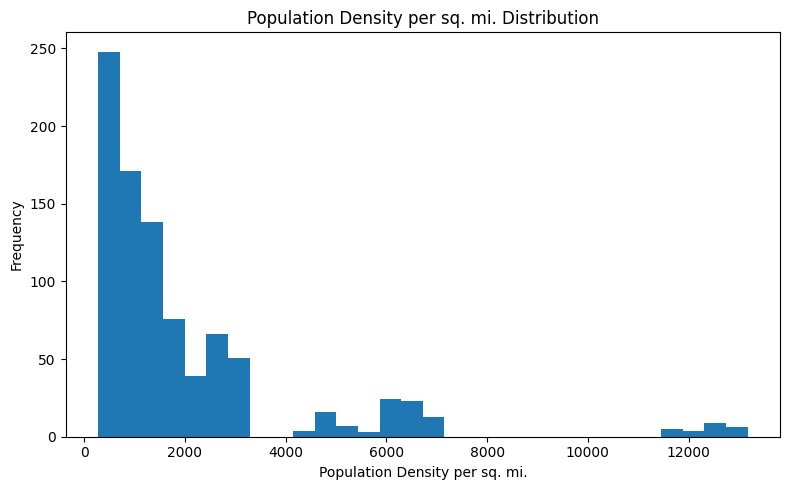

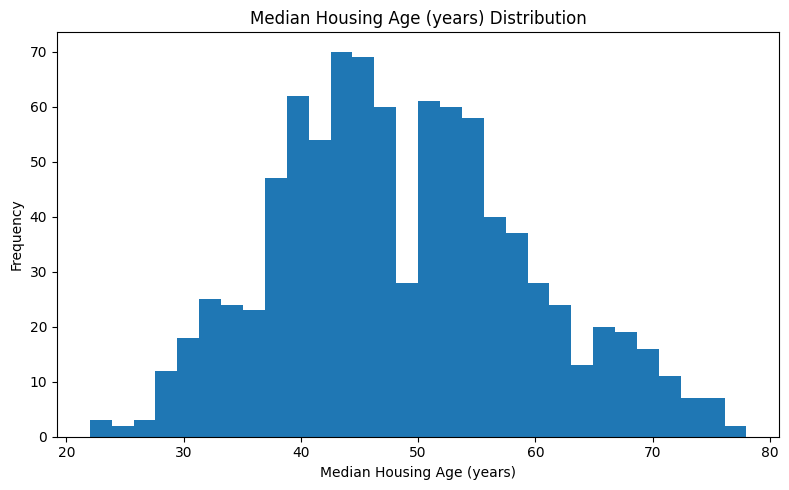

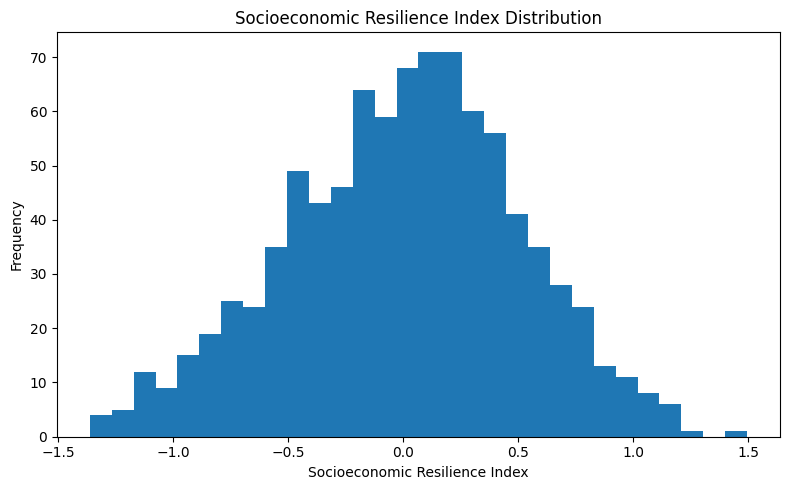

In [7]:
socioeconomic_variables = [
    ("median_income_usd", "Median Household Income (USD)", "figure_14_income_distribution.png"),
    ("population_density_per_sq_mi", "Population Density per sq. mi.", "figure_15_population_density.png"),
    ("housing_age_median_years", "Median Housing Age (years)", "figure_16_housing_age.png"),
    ("socioeconomic_resilience_index", "Socioeconomic Resilience Index", "figure_17_resilience_index.png"),
]
for variable, label, filename in socioeconomic_variables:
    plt.figure(figsize=(8, 5))
    plt.hist(df[variable], bins=30)
    plt.title(f"{label} Distribution")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    save_figure(filename)


**Interpretation.** Socioeconomic variables display substantial cross-county variation. Their direct bivariate associations with severity should be interpreted cautiously because RQ2 proposes moderation effects, which require interaction terms rather than simple correlations alone.

## 5. Correlation and multicollinearity analysis

,severity_metric,wind_speed_mph,flood_depth_feet,hail_size_inches,storm_duration_hours,log_property_damage,log_total_nfip_payout,nfip_claim_count,median_income_usd,population_density_per_sq_mi,housing_age_median_years,vacancy_rate_pct,homeownership_rate_pct,pct_units_pre1980,socioeconomic_resilience_index
severity_metric,1.000000,0.709861,0.380223,0.585332,0.575645,0.568195,0.259891,0.231662,-0.201004,-0.201587,-0.019522,-0.067432,-0.055432,-0.007967,-0.063735
wind_speed_mph,0.709861,1.000000,0.289726,0.251825,0.175057,0.464719,0.146621,0.174628,-0.203605,-0.211128,0.002061,-0.060371,-0.051378,0.013142,-0.082795
flood_depth_feet,0.380223,0.289726,1.000000,-0.236648,0.063363,0.085515,0.223280,0.343125,-0.136906,0.005659,0.083010,0.006325,0.032897,0.054440,-0.097778
hail_size_inches,0.585332,0.251825,-0.236648,1.000000,0.176024,0.169453,-0.076919,-0.096252,-0.093098,-0.207428,-0.130588,-0.064673,-0.077762,-0.113056,0.054242
storm_duration_hours,0.575645,0.175057,0.063363,0.176024,1.000000,0.249245,0.027222,0.024610,-0.042063,-0.050967,0.017064,-0.052384,-0.024372,0.041098,-0.028496
log_property_damage,0.568195,0.464719,0.085515,0.169453,0.249245,1.000000,0.108469,0.074788,-0.119543,-0.077227,0.015285,0.006523,-0.015715,0.017010,-0.068692
log_total_nfip_payout,0.259891,0.146621,0.223280,-0.076919,0.027222,0.108469,1.000000,0.592082,-0.041761,-0.005224,0.055229,-0.009286,0.000805,0.055806,-0.056312
nfip_claim_count,0.231662,0.174628,0.343125,-0.096252,0.024610,0.074788,0.592082,1.000000,-0.047666,-0.015584,0.076951,0.039418,0.017964,0.067426,-0.084248
median_income_usd,-0.201004,-0.203605,-0.136906,-0.093098,-0.042063,-0.119543,-0.041761,-0.047666,1.000000,0.003371,0.141139,0.050699,0.021967,0.148609,0.268933
population_density_per_sq_mi,-0.201587,-0.211128,0.005659,-0.207428,-0.050967,-0.077227,-0.005224,-0.015584,0.003371,1.000000,0.573932,0.090432,0.038725,0.529731,-0.454588


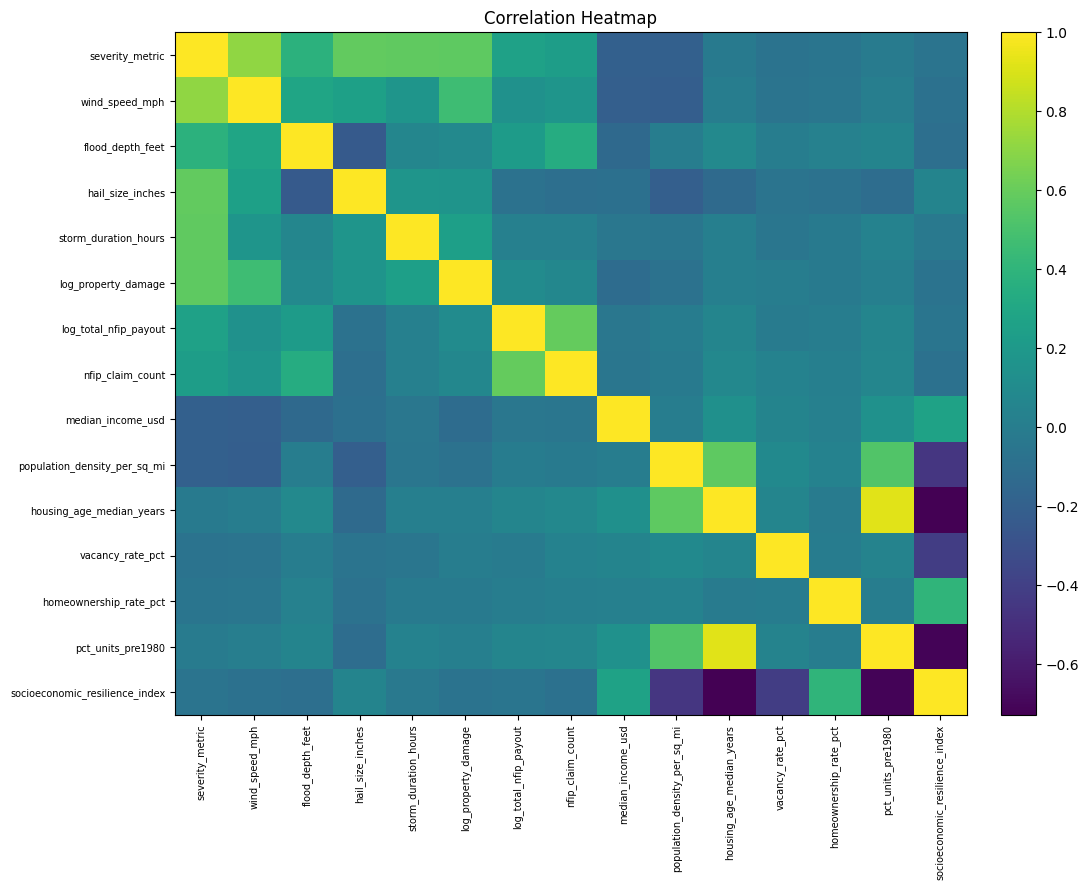

,Variable 1,Variable 2,Correlation,Absolute Correlation
97,housing_age_median_years,pct_units_pre1980,0.919458,0.919458
98,housing_age_median_years,socioeconomic_resilience_index,-0.728508,0.728508
104,pct_units_pre1980,socioeconomic_resilience_index,-0.714969,0.714969
0,severity_metric,wind_speed_mph,0.709861,0.709861
69,log_total_nfip_payout,nfip_claim_count,0.592082,0.592082
2,severity_metric,hail_size_inches,0.585332,0.585332
3,severity_metric,storm_duration_hours,0.575645,0.575645
90,population_density_per_sq_mi,housing_age_median_years,0.573932,0.573932
4,severity_metric,log_property_damage,0.568195,0.568195
93,population_density_per_sq_mi,pct_units_pre1980,0.529731,0.529731


In [8]:
analysis_features = [
    "severity_metric", "wind_speed_mph", "flood_depth_feet", "hail_size_inches",
    "storm_duration_hours", "log_property_damage", "log_total_nfip_payout",
    "nfip_claim_count", "median_income_usd", "population_density_per_sq_mi",
    "housing_age_median_years", "vacancy_rate_pct", "homeownership_rate_pct",
    "pct_units_pre1980", "socioeconomic_resilience_index",
]
correlation_matrix = df[analysis_features].corr()
correlation_matrix.to_csv(TABLE_DIR / "10_correlation_matrix.csv")
display(correlation_matrix)

plt.figure(figsize=(11, 9))
image = plt.imshow(correlation_matrix.values, aspect="auto")
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns,
           rotation=90, fontsize=7)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index, fontsize=7)
plt.title("Correlation Heatmap")
save_figure("figure_18_correlation_heatmap.png")

correlation_pairs = []
columns = list(correlation_matrix.columns)
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        value = correlation_matrix.iloc[i, j]
        correlation_pairs.append([columns[i], columns[j], value, abs(value)])
top_correlations = pd.DataFrame(
    correlation_pairs,
    columns=["Variable 1", "Variable 2", "Correlation", "Absolute Correlation"]
).sort_values("Absolute Correlation", ascending=False)
top_correlations.to_csv(TABLE_DIR / "11_top_correlations.csv", index=False)
display(top_correlations.head(20))


In [9]:
vif_features = [
    "wind_speed_mph", "flood_depth_feet", "hail_size_inches",
    "storm_duration_hours", "median_income_usd",
    "population_density_per_sq_mi", "housing_age_median_years",
    "vacancy_rate_pct", "homeownership_rate_pct", "pct_units_pre1980",
]
vif_data = df[vif_features].astype(float)
vif_scaled = (vif_data - vif_data.mean()) / vif_data.std(ddof=0)
vif_summary = pd.DataFrame({
    "Variable": vif_features,
    "VIF": [
        variance_inflation_factor(vif_scaled.values, index)
        for index in range(vif_scaled.shape[1])
    ],
}).sort_values("VIF", ascending=False)
vif_summary.to_csv(TABLE_DIR / "13_vif_summary.csv", index=False)
vif_summary


,Variable,VIF
6,housing_age_median_years,7.056021
9,pct_units_pre1980,6.560362
5,population_density_per_sq_mi,1.669591
0,wind_speed_mph,1.354578
2,hail_size_inches,1.270963
1,flood_depth_feet,1.259429
4,median_income_usd,1.114463
3,storm_duration_hours,1.063432
7,vacancy_rate_pct,1.015597
8,homeownership_rate_pct,1.011122


## 6. Hazard and socioeconomic relationships with severity

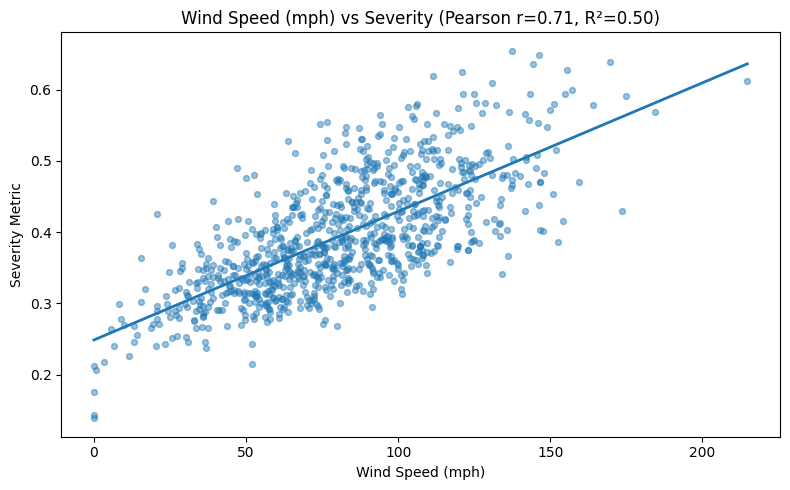

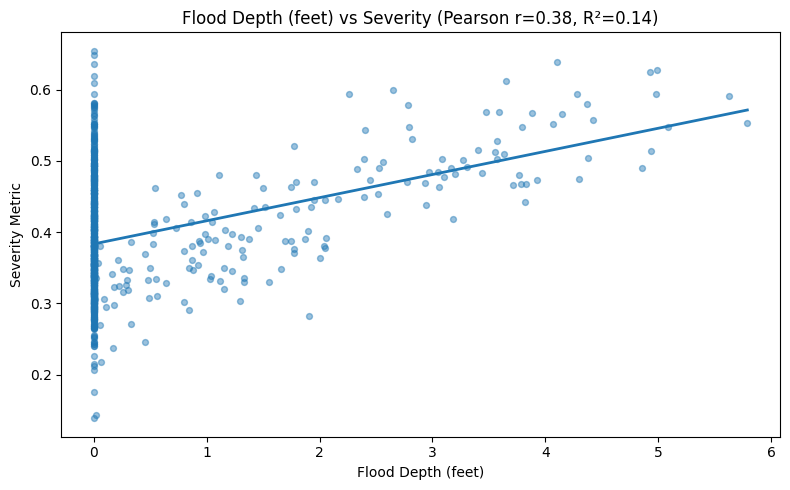

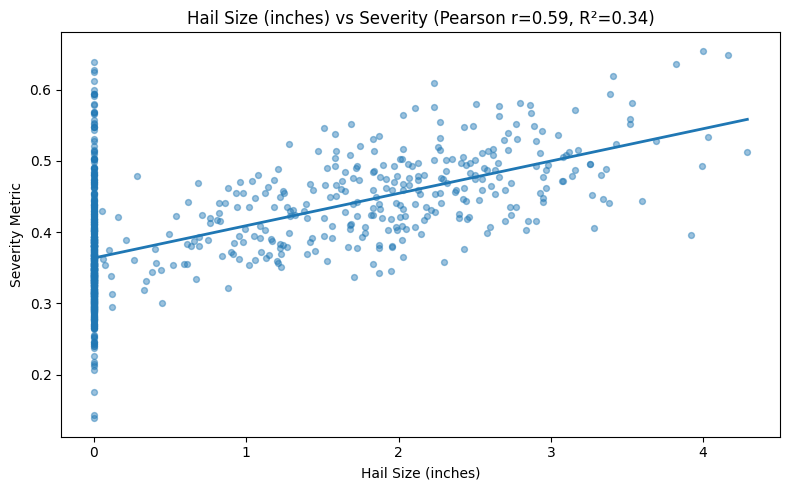

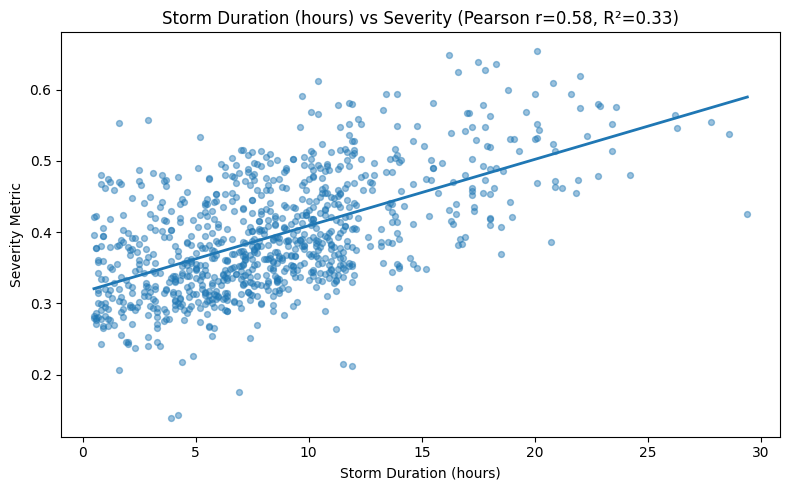

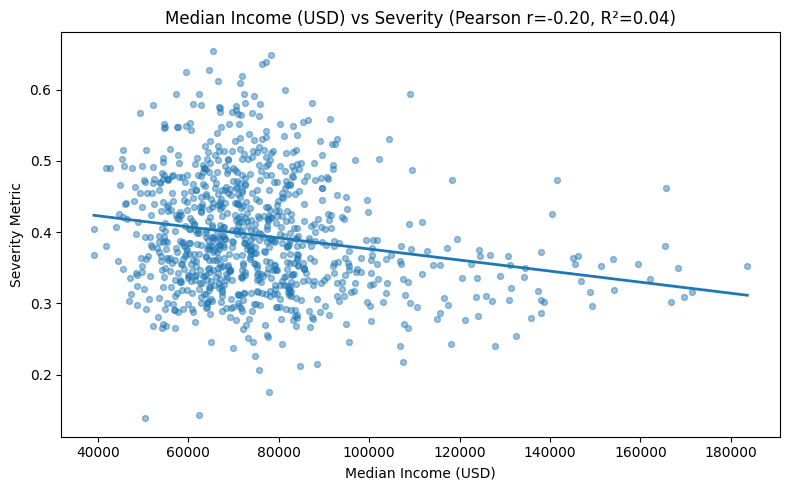

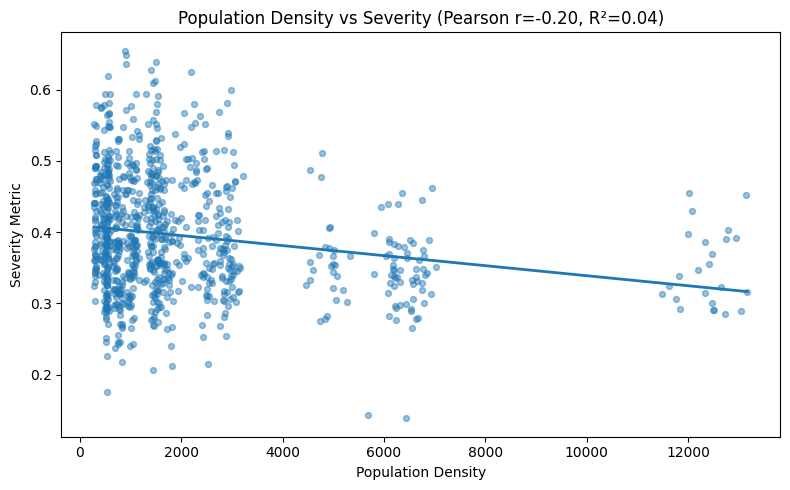

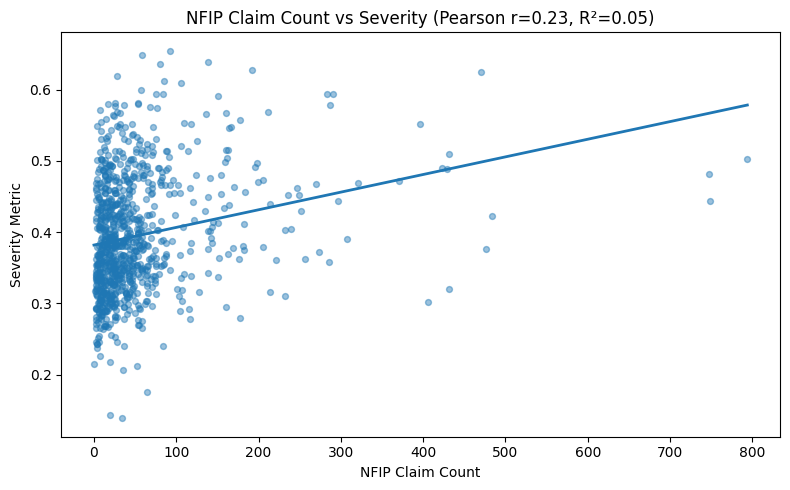

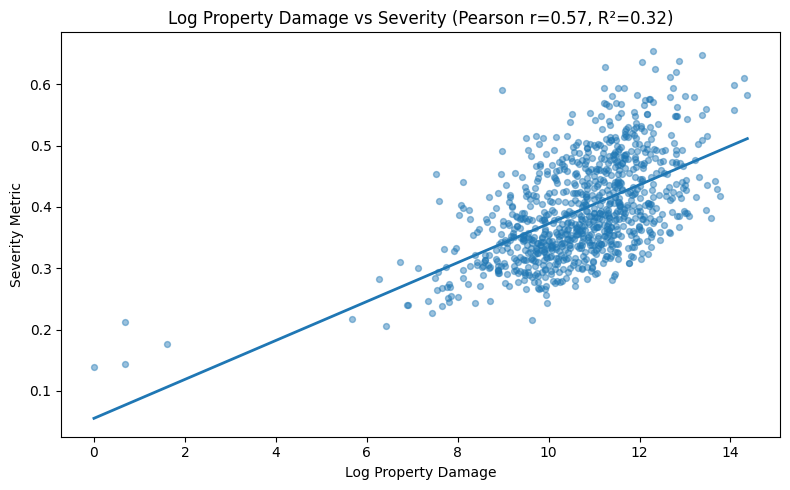

,Predictor,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,Linear R-squared
0,wind_speed_mph,0.709861,2.666775e-139,0.707317,6.978424e-138,0.503902
1,flood_depth_feet,0.380223,1.953943e-32,0.194794,3.589668e-09,0.144569
2,hail_size_inches,0.585332,3.841169e-84,0.590675,5.027248e-86,0.342613
3,storm_duration_hours,0.575645,8.137609e-81,0.541154,7.861702e-70,0.331367
4,median_income_usd,-0.201004,1.100505e-09,-0.176793,8.920622e-08,0.040403
5,population_density_per_sq_mi,-0.201587,9.829962e-10,-0.168702,3.413752e-07,0.040637
6,nfip_claim_count,0.231662,1.816462e-12,0.257713,3.638860e-15,0.053667
7,log_property_damage,0.568195,2.476518e-78,0.553310,1.478911e-73,0.322845


In [10]:
relationship_variables = [
    ("wind_speed_mph", "Wind Speed (mph)", "figure_19_wind_vs_severity.png"),
    ("flood_depth_feet", "Flood Depth (feet)", "figure_20_flood_vs_severity.png"),
    ("hail_size_inches", "Hail Size (inches)", "figure_21_hail_vs_severity.png"),
    ("storm_duration_hours", "Storm Duration (hours)", "figure_22_duration_vs_severity.png"),
    ("median_income_usd", "Median Income (USD)", "figure_23_income_vs_severity.png"),
    ("population_density_per_sq_mi", "Population Density", "figure_24_density_vs_severity.png"),
    ("nfip_claim_count", "NFIP Claim Count", "figure_25_nfip_claims_vs_severity.png"),
    ("log_property_damage", "Log Property Damage", "figure_26_property_damage_vs_severity.png"),
]

relationship_results = []

for variable, label, filename in relationship_variables:
    x = df[variable].astype(float)
    y = df["severity_metric"].astype(float)
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    regression = stats.linregress(x, y)

    relationship_results.append({
        "Predictor": variable,
        "Pearson r": pearson_r,
        "Pearson p-value": pearson_p,
        "Spearman rho": spearman_r,
        "Spearman p-value": spearman_p,
        "Linear R-squared": regression.rvalue ** 2,
    })

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=.45, s=18)
    x_line = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_line, regression.intercept + regression.slope * x_line, linewidth=2)
    plt.title(
        f"{label} vs Severity "
        f"(Pearson r={pearson_r:.2f}, R²={regression.rvalue ** 2:.2f})"
    )
    plt.xlabel(label)
    plt.ylabel("Severity Metric")
    save_figure(filename)

relationship_summary = pd.DataFrame(relationship_results)
relationship_summary.to_csv(TABLE_DIR / "12_relationship_statistics.csv", index=False)
relationship_summary


**Interpretation.** Among the displayed bivariate relationships, **`wind_speed_mph`** has the largest absolute Pearson correlation with the engineered severity metric (**r = 0.710**). Because the severity metric itself contains hazard and loss components, these associations describe the constructed outcome and should be followed by model diagnostics and sensitivity analyses.

## 7. Time trend and financial-loss summaries

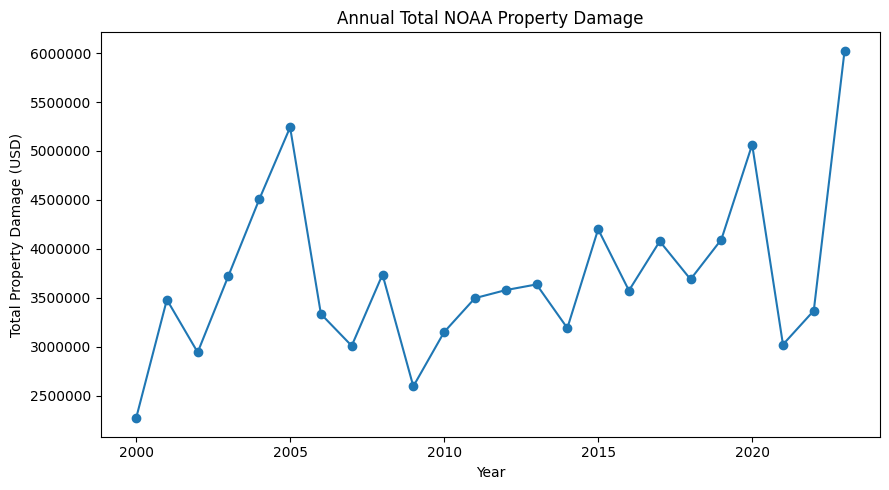

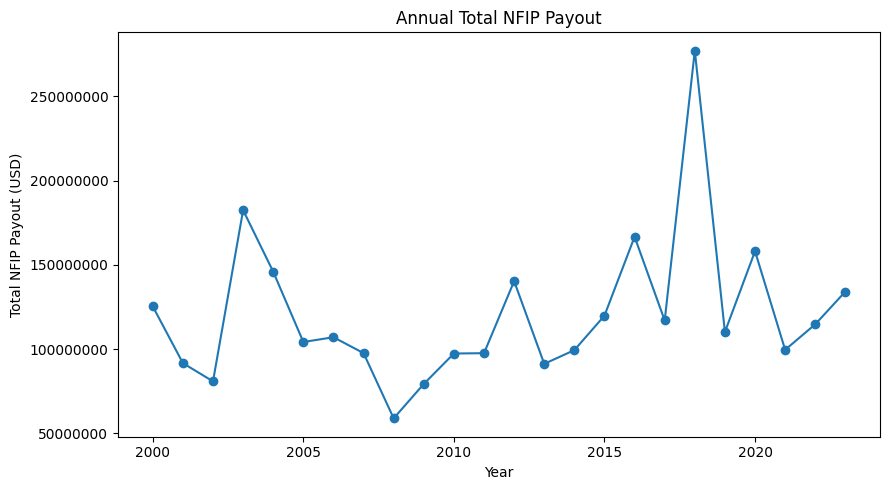

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(annual_summary["year"], annual_summary["total_property_damage"], marker="o")
plt.title("Annual Total NOAA Property Damage")
plt.xlabel("Year")
plt.ylabel("Total Property Damage (USD)")
plt.ticklabel_format(style="plain", axis="y")
save_figure("figure_29_annual_property_damage.png")

plt.figure(figsize=(9, 5))
plt.plot(annual_summary["year"], annual_summary["total_nfip_payout"], marker="o")
plt.title("Annual Total NFIP Payout")
plt.xlabel("Year")
plt.ylabel("Total NFIP Payout (USD)")
plt.ticklabel_format(style="plain", axis="y")
save_figure("figure_30_annual_nfip_payout.png")


**Interpretation.** The exploratory linear trend in annual mean severity has a slope of **0.001632 per year** with **p = 0.000**. This chart provides preliminary context for RQ4; the final time-series analysis should use the specified Mann-Kendall and ARIMA procedures before reaching a formal conclusion.

## 8. Machine-learning preparation and baseline Random Forest

In [12]:
target = "high_severity_flag"
feature_columns = [
    "wind_speed_mph", "flood_depth_feet", "hail_size_inches",
    "storm_duration_hours", "hazard_event_count", "event_type_count",
    "nfip_claim_count", "avg_building_payout_usd",
    "avg_contents_payout_usd", "total_nfip_payout_usd",
    "median_income_usd", "population_density_per_sq_mi",
    "housing_age_median_years", "vacancy_rate_pct",
    "homeownership_rate_pct", "pct_units_pre1980",
    "dominant_event_type", "construction_type", "year",
]

X = df[feature_columns].copy()
y = df[target].copy()
numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        numeric_columns,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]),
        categorical_columns,
    ),
])

baseline_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=3,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", baseline_model),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, stratify=y, random_state=42
)
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
probabilities = pipeline.predict_proba(X_test)[:, 1]

baseline_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions, zero_division=0),
    "Recall": recall_score(y_test, predictions, zero_division=0),
    "F1 Score": f1_score(y_test, predictions, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, probabilities),
    "Training Rows": len(X_train),
    "Test Rows": len(X_test),
}])
baseline_metrics.to_csv(TABLE_DIR / "14_baseline_random_forest_metrics.csv", index=False)
baseline_metrics


,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Rows,Test Rows
0,0.924779,0.833333,0.777778,0.804598,0.978637,677,226


,High Severity Flag,Count,Percentage
0,0,722,79.96
1,1,181,20.04


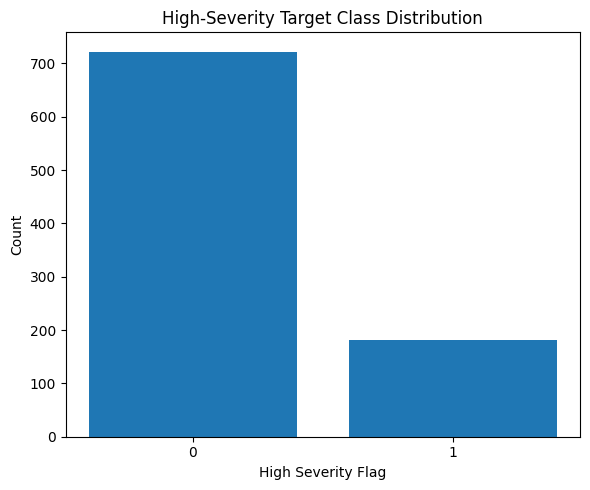

,Feature,Importance
2,hail_size_inches,0.191642
0,wind_speed_mph,0.179076
3,storm_duration_hours,0.119764
1,flood_depth_feet,0.086382
16,dominant_event_type,0.073062
4,hazard_event_count,0.049911
5,event_type_count,0.049037
6,nfip_claim_count,0.048261
9,total_nfip_payout_usd,0.036344
11,population_density_per_sq_mi,0.031424


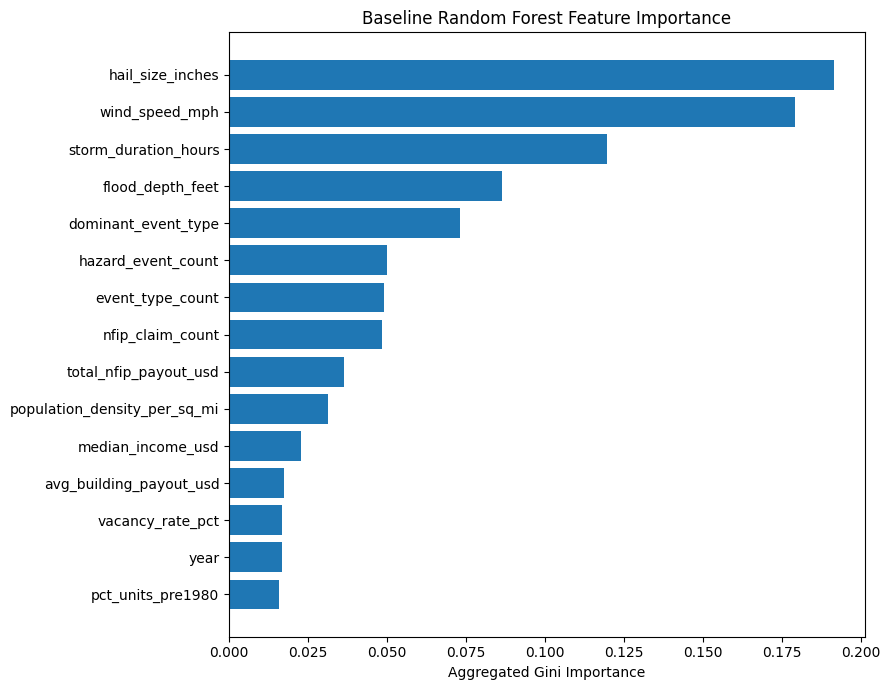

,Feature,Permutation Importance Mean,Permutation Importance SD
2,hail_size_inches,0.078140,0.008795
0,wind_speed_mph,0.045936,0.010963
3,storm_duration_hours,0.025089,0.004562
1,flood_depth_feet,0.024604,0.004410
5,event_type_count,0.004647,0.001829
16,dominant_event_type,0.003990,0.002606
4,hazard_event_count,0.003959,0.002444
11,population_density_per_sq_mi,0.000982,0.001890
8,avg_contents_payout_usd,-0.000012,0.000625
17,construction_type,-0.000068,0.000348


In [13]:
class_distribution = y.value_counts().sort_index().reset_index()
class_distribution.columns = ["High Severity Flag", "Count"]
class_distribution["Percentage"] = (
    class_distribution["Count"] / len(y) * 100
).round(2)
class_distribution.to_csv(TABLE_DIR / "15_target_class_distribution.csv", index=False)
display(class_distribution)

plt.figure(figsize=(6, 5))
plt.bar(class_distribution["High Severity Flag"].astype(str), class_distribution["Count"])
plt.title("High-Severity Target Class Distribution")
plt.xlabel("High Severity Flag")
plt.ylabel("Count")
save_figure("figure_27_target_class_distribution.png")

transformed_feature_names = (
    pipeline.named_steps["preprocessor"].get_feature_names_out()
)
raw_importances = pipeline.named_steps["model"].feature_importances_

aggregated_importance = []
for original_feature in feature_columns:
    importance = 0
    for transformed_feature, transformed_importance in zip(
        transformed_feature_names, raw_importances
    ):
        if (
            transformed_feature.startswith("numeric__" + original_feature)
            or transformed_feature.startswith("categorical__" + original_feature + "_")
        ):
            importance += transformed_importance
    aggregated_importance.append({
        "Feature": original_feature,
        "Importance": importance,
    })

feature_importance = (
    pd.DataFrame(aggregated_importance)
      .sort_values("Importance", ascending=False)
)
feature_importance.to_csv(TABLE_DIR / "16_feature_importance.csv", index=False)
display(feature_importance)

plt.figure(figsize=(9, 7))
importance_plot = feature_importance.head(15).sort_values("Importance")
plt.barh(importance_plot["Feature"], importance_plot["Importance"])
plt.title("Baseline Random Forest Feature Importance")
plt.xlabel("Aggregated Gini Importance")
save_figure("figure_28_feature_importance.png")

permutation_results = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=20, random_state=42, scoring="roc_auc"
)
permutation_table = pd.DataFrame({
    "Feature": feature_columns,
    "Permutation Importance Mean": permutation_results.importances_mean,
    "Permutation Importance SD": permutation_results.importances_std,
}).sort_values("Permutation Importance Mean", ascending=False)
permutation_table.to_csv(TABLE_DIR / "17_permutation_importance.csv", index=False)
permutation_table


**Interpretation.** The exploratory baseline Random Forest achieved **ROC-AUC = 0.979** and **F1 = 0.805** on the held-out test set. The strongest aggregated feature importance was **`hail_size_inches`**. These results show that the dataset is suitable for RQ3 modeling, but they are not final performance estimates because formal tuning, cross-validation, calibration, and model comparison remain for Phase 4.

## 9. EDA findings summary

- **Dataset readiness:** The EDA used 903 county-year observations covering 2000–2023 and 50 counties. No missing values or duplicate county-year keys remained.
- **Severity distribution:** The severity metric had a median of 0.383; the high-severity cutoff was 0.469, producing 181 high-severity observations.
- **Hazard relationship:** wind_speed_mph had the largest absolute Pearson association with severity among the plotted predictors (r=0.710).
- **Event type:** Hurricane (Typhoon) had the highest mean severity (0.489) among dominant event types.
- **County pattern:** Miami-Dade, FL had the highest mean severity (0.498) in the supplied data.
- **Annual trend:** The linear annual mean-severity trend slope was 0.001632 per year with p=0.000; this is exploratory rather than a final RQ4 inference.
- **ML readiness:** The baseline Random Forest achieved ROC-AUC=0.979 and F1=0.805. The highest aggregated feature importance was hail_size_inches (0.192).

In [14]:
eda_findings = pd.DataFrame([
    ["Dataset readiness", "The integrated county-year dataset passed completeness and uniqueness checks."],
    ["Hazard distributions", "Hazard and loss variables are right-skewed and contain meaningful extremes."],
    ["Severity", "The 80th-percentile rule provides a transparent high-severity classification target."],
    ["Socioeconomic context", "Socioeconomic variables vary substantially and should be tested through moderation models."],
    ["Correlations", "Correlation and VIF tables provide diagnostics for later regression specification."],
    ["Trend analysis", "Annual patterns are exploratory and require formal Mann-Kendall and ARIMA analysis."],
    ["Machine learning", "The baseline model demonstrates predictive signal but is not a final tuned model."],
], columns=["Topic", "Interpretation"])
eda_findings.to_csv(TABLE_DIR / "18_eda_findings_summary.csv", index=False)
eda_findings


,Topic,Interpretation
0,Dataset readiness,The integrated county-year dataset passed comp...
1,Hazard distributions,Hazard and loss variables are right-skewed and...
2,Severity,The 80th-percentile rule provides a transparen...
3,Socioeconomic context,Socioeconomic variables vary substantially and...
4,Correlations,Correlation and VIF tables provide diagnostics...
5,Trend analysis,Annual patterns are exploratory and require fo...
6,Machine learning,The baseline model demonstrates predictive sig...
